In [1]:
# ==========================================================
# Grad-CAM Explainability - HEp-2
# ----------------------------------------------------------
# Objective 2:
# Generate Grad-CAM saliency maps to visualize the regions
# influencing the HEp-2 pattern classification.
# ==========================================================

import torch
import torch.nn as nn
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ----------------------------------------------------------
# Classes
# ----------------------------------------------------------

class_names = [
    "Centromere",
    "Golgi",
    "Homogeneous",
    "NuMem",
    "Nucleolar",
    "Speckled"
]

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# ----------------------------------------------------------
# Model paths
# ----------------------------------------------------------

RESNET_PATH = "resnet50_best.pth"
DENSENET_PATH = "densenet121_best.pth"

print("ResNet50 model:", RESNET_PATH)
print("DenseNet121 model:", DENSENET_PATH)

# ----------------------------------------------------------
# Image preprocessing
# ----------------------------------------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Grad-CAM setup completed successfully.")

Device: cpu
Classes: ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']
Number of classes: 6
ResNet50 model: resnet50_best.pth
DenseNet121 model: densenet121_best.pth
Grad-CAM setup completed successfully.


In [2]:
# ==========================================================
# Load Trained Models
# ==========================================================

# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

resnet50 = models.resnet50(weights=None)

resnet50.fc = nn.Linear(
    resnet50.fc.in_features,
    num_classes
)

resnet50.load_state_dict(
    torch.load(RESNET_PATH, map_location=device)
)

resnet50 = resnet50.to(device)
resnet50.eval()


# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

densenet121 = models.densenet121(weights=None)

densenet121.classifier = nn.Linear(
    densenet121.classifier.in_features,
    num_classes
)

densenet121.load_state_dict(
    torch.load(DENSENET_PATH, map_location=device)
)

densenet121 = densenet121.to(device)
densenet121.eval()


# ----------------------------------------------------------
# Verification
# ----------------------------------------------------------

print("=" * 60)
print("TRAINED MODELS LOADED")
print("=" * 60)

print("ResNet50   : Loaded successfully")
print("DenseNet121 : Loaded successfully")
print("Device      :", device)

TRAINED MODELS LOADED
ResNet50   : Loaded successfully
DenseNet121 : Loaded successfully
Device      : cpu


In [3]:
# ==========================================================
# Grad-CAM Target Layers
# ==========================================================

# ResNet50: final convolutional block
resnet_target_layer = resnet50.layer4[-1]

# DenseNet121: final convolutional layer
densenet_target_layer = densenet121.features.denseblock4.denselayer16.conv2

print("=" * 60)
print("GRAD-CAM TARGET LAYERS")
print("=" * 60)

print("ResNet50 target layer   :", resnet_target_layer)
print("DenseNet121 target layer:", densenet_target_layer)

GRAD-CAM TARGET LAYERS
ResNet50 target layer   : Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)
DenseNet121 target layer: Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [4]:
# ==========================================================
# Grad-CAM Implementation
# ==========================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Forward hook
        self.forward_handle = target_layer.register_forward_hook(
            self.save_activation
        )

        # Backward hook
        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_index=None):

        self.model.zero_grad()

        output = self.model(image_tensor)

        # If no class is specified, use predicted class
        if class_index is None:
            class_index = output.argmax(dim=1).item()

        # Score corresponding to target class
        score = output[:, class_index]

        # Backpropagate
        score.backward()

        # Get activations and gradients
        activations = self.activations
        gradients = self.gradients

        # Global average pooling of gradients
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted combination of feature maps
        cam = (weights * activations).sum(dim=1)

        # ReLU: keep only positive influence
        cam = torch.relu(cam)

        # Convert to numpy
        cam = cam.squeeze().cpu().numpy()

        # Normalize between 0 and 1
        cam -= cam.min()

        if cam.max() > 0:
            cam /= cam.max()

        return cam, class_index, output


print("Grad-CAM class defined successfully.")

Grad-CAM class defined successfully.


In [5]:
# ==========================================================
# Initialize Grad-CAM for Both Models
# ==========================================================

resnet_gradcam = GradCAM(
    model=resnet50,
    target_layer=resnet_target_layer
)

densenet_gradcam = GradCAM(
    model=densenet121,
    target_layer=densenet_target_layer
)

print("=" * 60)
print("GRAD-CAM INITIALIZED")
print("=" * 60)

print("ResNet50   : Ready")
print("DenseNet121: Ready")

GRAD-CAM INITIALIZED
ResNet50   : Ready
DenseNet121: Ready


In [6]:
# ==========================================================
# Recreate Exact HEp-2 Test Dataset
# ----------------------------------------------------------
# Uses the SAME:
# - dataset path
# - class ordering
# - train/validation/test split
# - test preprocessing
# - HEP2Dataset class
#
# This reproduces the original 2040-image test set.
# ==========================================================

import os
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

# ----------------------------------------------------------
# Dataset path
# ----------------------------------------------------------

data_dir = os.path.join("hep2_data", "data")

# Same class ordering as original notebook
class_names = sorted([
    folder
    for folder in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, folder))
])

# ----------------------------------------------------------
# Create image metadata
# ----------------------------------------------------------

image_records = []

for class_name in class_names:

    class_path = os.path.join(data_dir, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith((".png", ".jpg", ".jpeg")):

            image_records.append({
                "image_path": os.path.join(
                    class_path,
                    file_name
                ),
                "label": class_name
            })

df = pd.DataFrame(image_records)

# ----------------------------------------------------------
# EXACT SAME 70 / 15 / 15 STRATIFIED SPLIT
# ----------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

# ----------------------------------------------------------
# Label mapping
# ----------------------------------------------------------

label_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

index_to_label = {
    index: class_name
    for class_name, index in label_to_index.items()
}

# ----------------------------------------------------------
# Exact test transformation
# ----------------------------------------------------------

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ----------------------------------------------------------
# Dataset class
# ----------------------------------------------------------

class HEP2Dataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        image_path = self.dataframe.loc[
            index, "image_path"
        ]

        label_name = self.dataframe.loc[
            index, "label"
        ]

        image = Image.open(image_path).convert("L")
        image = image.convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = label_to_index[label_name]

        return image, label

# ----------------------------------------------------------
# Create exact test dataset
# ----------------------------------------------------------

test_dataset = HEP2Dataset(
    test_df,
    transform=val_test_transform
)

print("=" * 60)
print("EXACT TEST DATASET READY")
print("=" * 60)

print("Total images :", len(df))
print("Test images  :", len(test_dataset))
print("Classes      :", class_names)

EXACT TEST DATASET READY
Total images : 13596
Test images  : 2040
Classes      : ['Centromere', 'Golgi', 'Homogeneous', 'NuMem', 'Nucleolar', 'Speckled']


In [7]:
# ==========================================================
# Install Grad-CAM
# ==========================================================

!pip install -q grad-cam

print("Grad-CAM installed successfully.")

Grad-CAM installed successfully.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# ==========================================================
# Reload Trained ResNet50 and DenseNet121 Models
# ----------------------------------------------------------
# Purpose:
# Load the already-trained models for Grad-CAM.
# NO TRAINING IS HAPPENING HERE.
# ==========================================================

import torch
import torch.nn as nn
from torchvision import models

# ----------------------------------------------------------
# Device
# ----------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ----------------------------------------------------------
# ResNet50
# ----------------------------------------------------------

resnet_model = models.resnet50(weights=None)

resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    len(class_names)
)

resnet_model.load_state_dict(
    torch.load(
        "resnet50_best.pth",
        map_location=device
    )
)

resnet_model = resnet_model.to(device)
resnet_model.eval()

# ----------------------------------------------------------
# DenseNet121
# ----------------------------------------------------------

densenet_model = models.densenet121(weights=None)

densenet_model.classifier = nn.Linear(
    densenet_model.classifier.in_features,
    len(class_names)
)

densenet_model.load_state_dict(
    torch.load(
        "densenet121_best.pth",
        map_location=device
    )
)

densenet_model = densenet_model.to(device)
densenet_model.eval()

print("\n" + "=" * 60)
print("TRAINED MODELS LOADED FOR GRAD-CAM")
print("=" * 60)

print("ResNet50  : resnet50_best.pth")
print("DenseNet121: densenet121_best.pth")
print("Number of classes:", len(class_names))

Device: cpu

TRAINED MODELS LOADED FOR GRAD-CAM
ResNet50  : resnet50_best.pth
DenseNet121: densenet121_best.pth
Number of classes: 6


In [8]:
resnet_target_layer = resnet_model.layer4[-1]
densenet_target_layer = densenet_model.features.norm5

print("=" * 60)
print("GRAD-CAM TARGET LAYERS")
print("=" * 60)

print("ResNet50 target layer:")
print(resnet_target_layer)

print("\nDenseNet121 target layer:")
print(densenet_target_layer)

GRAD-CAM TARGET LAYERS
ResNet50 target layer:
Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)

DenseNet121 target layer:
BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)


GRAD-CAM INTERPRETABILITY ANALYSIS

True pattern:
  NuMem

------------------------------------------------------------
RESNET50
------------------------------------------------------------
Predicted pattern : NuMem
Confidence        : 99.86%
Attention region  : central region
High-activation area : 20.00% of image

Interpretation:
  The central region contains the strongest Grad-CAM activation and therefore contributed strongly to the model's NuMem prediction.

------------------------------------------------------------
DENSENET121
------------------------------------------------------------
Predicted pattern : NuMem
Confidence        : 99.90%
Attention region  : central region
High-activation area : 20.00% of image

Interpretation:
  The central region contains the strongest Grad-CAM activation and therefore contributed strongly to the model's NuMem prediction.


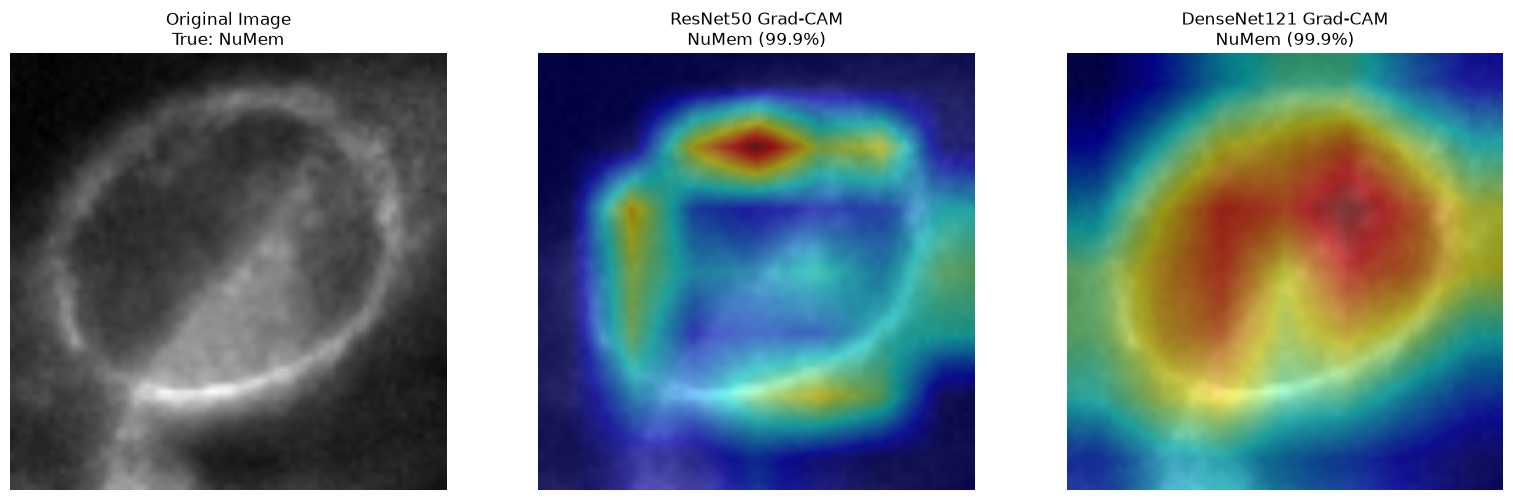

In [9]:
# ==========================================================
# Grad-CAM + Confidence + Attention Analysis
# ----------------------------------------------------------
# Objective 2:
# Generate an interpretable explanation of the model's
# prediction using Grad-CAM.
#
# Important:
# Grad-CAM identifies image regions contributing strongly
# to the prediction. It does NOT prove a medical diagnosis
# or identify a biological structure by itself.
# ==========================================================

import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


# ==========================================================
# Select one test image
# ==========================================================

sample_index = random.randrange(len(test_dataset))

image_tensor, true_label = test_dataset[sample_index]

input_tensor = image_tensor.unsqueeze(0).to(device)


# ==========================================================
# Model predictions
# ==========================================================

resnet_model.eval()
densenet_model.eval()

with torch.no_grad():

    resnet_output = resnet_model(input_tensor)
    densenet_output = densenet_model(input_tensor)

    # Convert logits to probabilities
    resnet_probabilities = torch.softmax(
        resnet_output, dim=1
    )

    densenet_probabilities = torch.softmax(
        densenet_output, dim=1
    )

    resnet_prediction = torch.argmax(
        resnet_probabilities, dim=1
    ).item()

    densenet_prediction = torch.argmax(
        densenet_probabilities, dim=1
    ).item()

    resnet_confidence = (
        resnet_probabilities[0, resnet_prediction].item()
        * 100
    )

    densenet_confidence = (
        densenet_probabilities[0, densenet_prediction].item()
        * 100
    )


# ==========================================================
# Generate Grad-CAM
# ==========================================================

resnet_cam = GradCAM(
    model=resnet_model,
    target_layers=[resnet_target_layer]
)

densenet_cam = GradCAM(
    model=densenet_model,
    target_layers=[densenet_target_layer]
)


resnet_grayscale_cam = resnet_cam(
    input_tensor=input_tensor,
    targets=[
        ClassifierOutputTarget(resnet_prediction)
    ]
)[0]


densenet_grayscale_cam = densenet_cam(
    input_tensor=input_tensor,
    targets=[
        ClassifierOutputTarget(densenet_prediction)
    ]
)[0]


# ==========================================================
# Calculate attention statistics
# ==========================================================

def analyze_attention(cam):

    # Average activation
    mean_activation = float(np.mean(cam))

    # Maximum activation
    max_activation = float(np.max(cam))

    # Pixels belonging to the strongest 20% activation
    threshold = np.percentile(cam, 80)

    high_activation = cam >= threshold

    attention_percentage = (
        np.sum(high_activation) /
        high_activation.size
    ) * 100

    # Center of high-activation region
    y_coords, x_coords = np.where(high_activation)

    if len(x_coords) > 0:

        center_x = np.mean(x_coords) / cam.shape[1]
        center_y = np.mean(y_coords) / cam.shape[0]

    else:

        center_x = 0.5
        center_y = 0.5

    # Describe approximate image location
    if center_y < 0.33:
        vertical = "upper"
    elif center_y > 0.66:
        vertical = "lower"
    else:
        vertical = "central"

    if center_x < 0.33:
        horizontal = "left"
    elif center_x > 0.66:
        horizontal = "right"
    else:
        horizontal = "central"

    if vertical == "central" and horizontal == "central":
        location = "central region"
    else:
        location = f"{vertical}-{horizontal} region"

    return (
        mean_activation,
        max_activation,
        attention_percentage,
        location
    )


resnet_attention = analyze_attention(
    resnet_grayscale_cam
)

densenet_attention = analyze_attention(
    densenet_grayscale_cam
)


# ==========================================================
# Restore original image
# ==========================================================

image_np = image_tensor.cpu().numpy()

image_np = np.transpose(
    image_np,
    (1, 2, 0)
)

mean = np.array(
    [0.485, 0.456, 0.406]
)

std = np.array(
    [0.229, 0.224, 0.225]
)

image_np = image_np * std + mean

image_np = np.clip(
    image_np,
    0,
    1
)


# ==========================================================
# Create Grad-CAM overlays
# ==========================================================

resnet_visualization = show_cam_on_image(
    image_np,
    resnet_grayscale_cam,
    use_rgb=True
)

densenet_visualization = show_cam_on_image(
    image_np,
    densenet_grayscale_cam,
    use_rgb=True
)


# ==========================================================
# Print interpretable results
# ==========================================================

print("=" * 65)
print("GRAD-CAM INTERPRETABILITY ANALYSIS")
print("=" * 65)

print("\nTrue pattern:")
print(f"  {class_names[true_label]}")


print("\n------------------------------------------------------------")
print("RESNET50")
print("------------------------------------------------------------")

print(
    f"Predicted pattern : "
    f"{class_names[resnet_prediction]}"
)

print(
    f"Confidence        : "
    f"{resnet_confidence:.2f}%"
)

print(
    f"Attention region  : "
    f"{resnet_attention[3]}"
)

print(
    f"High-activation area : "
    f"{resnet_attention[2]:.2f}% of image"
)

print(
    "\nInterpretation:"
)

print(
    f"  The {resnet_attention[3]} contains the strongest "
    f"Grad-CAM activation and therefore contributed strongly "
    f"to the model's {class_names[resnet_prediction]} prediction."
)


print("\n------------------------------------------------------------")
print("DENSENET121")
print("------------------------------------------------------------")

print(
    f"Predicted pattern : "
    f"{class_names[densenet_prediction]}"
)

print(
    f"Confidence        : "
    f"{densenet_confidence:.2f}%"
)

print(
    f"Attention region  : "
    f"{densenet_attention[3]}"
)

print(
    f"High-activation area : "
    f"{densenet_attention[2]:.2f}% of image"
)

print(
    "\nInterpretation:"
)

print(
    f"  The {densenet_attention[3]} contains the strongest "
    f"Grad-CAM activation and therefore contributed strongly "
    f"to the model's {class_names[densenet_prediction]} prediction."
)


# ==========================================================
# Display
# ==========================================================

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)

plt.imshow(image_np)

plt.title(
    f"Original Image\n"
    f"True: {class_names[true_label]}"
)

plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(resnet_visualization)

plt.title(
    f"ResNet50 Grad-CAM\n"
    f"{class_names[resnet_prediction]} "
    f"({resnet_confidence:.1f}%)"
)

plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(densenet_visualization)

plt.title(
    f"DenseNet121 Grad-CAM\n"
    f"{class_names[densenet_prediction]} "
    f"({densenet_confidence:.1f}%)"
)

plt.axis("off")


plt.tight_layout()
plt.show()

GRAD-CAM SAMPLES SELECTED
Centromere      -> Test index 0
Golgi           -> Test index 21
Homogeneous     -> Test index 2
NuMem           -> Test index 3
Nucleolar       -> Test index 7
Speckled        -> Test index 1


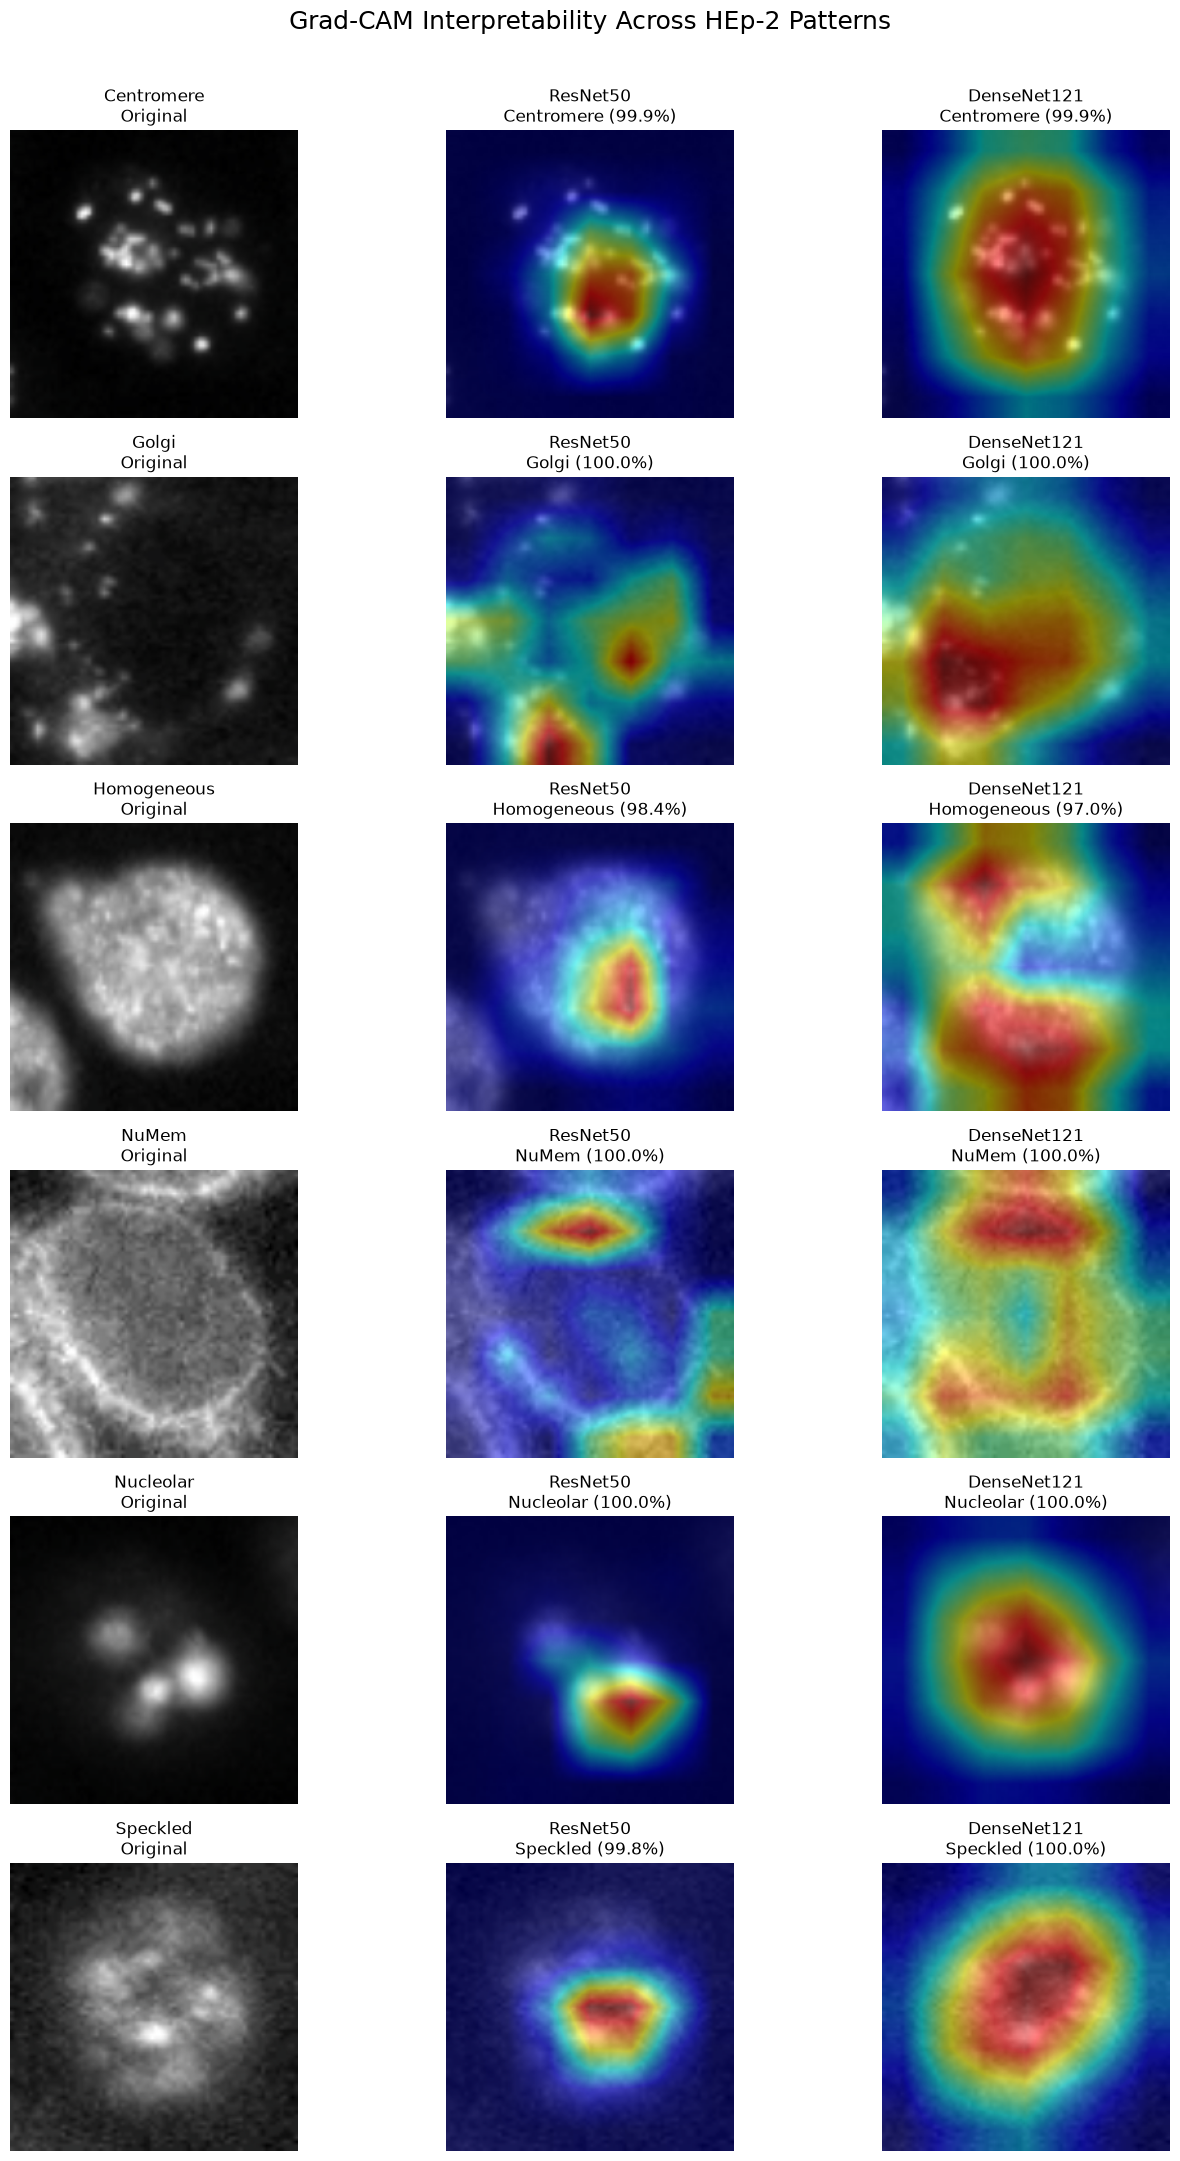

In [10]:
# ==========================================================
# Grad-CAM Analysis Across All 6 HEp-2 Classes
# ----------------------------------------------------------
# Objective 2:
# Generate representative Grad-CAM explanations for all
# six HEp-2 staining-pattern classes.
#
# Only images correctly classified by BOTH models are used.
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import torch

# ----------------------------------------------------------
# Find one correctly classified test image per class
# ----------------------------------------------------------

selected_samples = {}

resnet_model.eval()
densenet_model.eval()

for idx in range(len(test_dataset)):

    image_tensor, true_label = test_dataset[idx]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        resnet_output = resnet_model(input_tensor)
        densenet_output = densenet_model(input_tensor)

        resnet_prediction = torch.argmax(
            resnet_output, dim=1
        ).item()

        densenet_prediction = torch.argmax(
            densenet_output, dim=1
        ).item()

    # Keep only samples where BOTH models are correct
    if (
        resnet_prediction == true_label
        and densenet_prediction == true_label
        and true_label not in selected_samples
    ):
        selected_samples[true_label] = (
            idx,
            image_tensor,
            true_label
        )

    # Stop once all 6 classes are represented
    if len(selected_samples) == len(class_names):
        break


# ----------------------------------------------------------
# Display selected samples
# ----------------------------------------------------------

print("=" * 60)
print("GRAD-CAM SAMPLES SELECTED")
print("=" * 60)

for label_idx in sorted(selected_samples):

    sample_index = selected_samples[label_idx][0]

    print(
        f"{class_names[label_idx]:15s} "
        f"-> Test index {sample_index}"
    )


# ----------------------------------------------------------
# Create figure
# ----------------------------------------------------------

fig, axes = plt.subplots(
    len(class_names),
    3,
    figsize=(14, 22)
)


# ----------------------------------------------------------
# Generate Grad-CAM for each class
# ----------------------------------------------------------

for row, label_idx in enumerate(sorted(selected_samples)):

    sample_index, image_tensor, true_label = (
        selected_samples[label_idx]
    )

    input_tensor = image_tensor.unsqueeze(0).to(device)

    # ------------------------------------------------------
    # Predictions + confidence
    # ------------------------------------------------------

    with torch.no_grad():

        resnet_output = resnet_model(input_tensor)
        densenet_output = densenet_model(input_tensor)

        resnet_probabilities = torch.softmax(
            resnet_output, dim=1
        )

        densenet_probabilities = torch.softmax(
            densenet_output, dim=1
        )

        resnet_prediction = torch.argmax(
            resnet_probabilities, dim=1
        ).item()

        densenet_prediction = torch.argmax(
            densenet_probabilities, dim=1
        ).item()

        resnet_confidence = (
            resnet_probabilities[
                0, resnet_prediction
            ].item() * 100
        )

        densenet_confidence = (
            densenet_probabilities[
                0, densenet_prediction
            ].item() * 100
        )


    # ------------------------------------------------------
    # Grad-CAM
    # ------------------------------------------------------

    resnet_grayscale_cam = resnet_cam(
        input_tensor=input_tensor,
        targets=[
            ClassifierOutputTarget(resnet_prediction)
        ]
    )[0]

    densenet_grayscale_cam = densenet_cam(
        input_tensor=input_tensor,
        targets=[
            ClassifierOutputTarget(densenet_prediction)
        ]
    )[0]


    # ------------------------------------------------------
    # Restore original image
    # ------------------------------------------------------

    image_np = image_tensor.cpu().numpy()

    image_np = np.transpose(
        image_np,
        (1, 2, 0)
    )

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    image_np = image_np * std + mean

    image_np = np.clip(
        image_np,
        0,
        1
    )


    # ------------------------------------------------------
    # Create heatmap overlays
    # ------------------------------------------------------

    resnet_visualization = show_cam_on_image(
        image_np,
        resnet_grayscale_cam,
        use_rgb=True
    )

    densenet_visualization = show_cam_on_image(
        image_np,
        densenet_grayscale_cam,
        use_rgb=True
    )


    # ------------------------------------------------------
    # Original image
    # ------------------------------------------------------

    axes[row, 0].imshow(image_np)

    axes[row, 0].set_title(
        f"{class_names[true_label]}\n"
        f"Original"
    )

    axes[row, 0].axis("off")


    # ------------------------------------------------------
    # ResNet50 Grad-CAM
    # ------------------------------------------------------

    axes[row, 1].imshow(
        resnet_visualization
    )

    axes[row, 1].set_title(
        f"ResNet50\n"
        f"{class_names[resnet_prediction]} "
        f"({resnet_confidence:.1f}%)"
    )

    axes[row, 1].axis("off")


    # ------------------------------------------------------
    # DenseNet121 Grad-CAM
    # ------------------------------------------------------

    axes[row, 2].imshow(
        densenet_visualization
    )

    axes[row, 2].set_title(
        f"DenseNet121\n"
        f"{class_names[densenet_prediction]} "
        f"({densenet_confidence:.1f}%)"
    )

    axes[row, 2].axis("off")


# ----------------------------------------------------------
# Final layout
# ----------------------------------------------------------

plt.suptitle(
    "Grad-CAM Interpretability Across HEp-2 Patterns",
    fontsize=18
)

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

plt.show()